<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Word%20Embeddings%20Word2Vec%20%C3%A9s%20GloVe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

© 2025 by Barbara Noémi Szabó is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# Szóbeágyazások (Word Embeddings)

A Természetes Nyelvfeldolgozás (NLP - Natural Language Processing) a mesterséges intelligencia (MI) azon területe, amely lehetővé teszi a számítógépek számára az **emberi nyelv megértését, értelmezését és generálását**. Ez teszi lehetővé, hogy a gépek természetes módon kommunikáljanak az emberekkel. Néhány példa NLP feladatokra:

* Beszédfelismerés (pl. hangalapú asszisztensek, mint a Siri, Alexa)
* Szövegelemzés (pl. szentimentelemzés)
* Gépi fordítás (pl. Google Fordító)
* Chatbotok és virtuális asszisztensek (pl. ChatGPT)
* Információ-visszakeresés (pl. keresőmotorok)
* Összefoglalás és szöveggenerálás

## 1. Szöveg előfeldolgozás

A feladattól függően (később példákat fogunk látni erre) számos előfeldolgozási lépést alkalmazhatunk. Ebben a fejezetben néhány technikát fogunk megvizsgálni.

In [ ]:
import os
import re
import spacy
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import nltk

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from textblob import TextBlob
from transformers import BertTokenizer
from torch.utils.data import DataLoader

**Kisbetűsítés**

Az összes szöveg kisbetűssé alakítása az egységesség érdekében (pl. "Kutya" -> "kutya")

In [ ]:
text = "The quick brown Fox jumped over the lazy dog."
text.lower()

'the quick brown fox jumped over the lazy dog.'

**Tokenizálás**

A szöveg szavakra vagy részszavakra (token) bontása (pl. "A lusta kutya" -> ["A", "lusta", "kutya"]). A tokenek használata a teljes szavak helyett gyakran előnyös, különösen olyan esetekben, mint:

* Ritka szavak kezelése: sok szónak van előtagja, utótagja vagy változata ("futás", "fut", "futó") és néhány teljesen ismeretlen (OOV - out-of-vocabulary), tehát a modell nem látta korábban a tanítás során
* Szókincs méretének csökkentése: pl. Szóalapú: "beszél", "beszélt", "beszélnek" -> 3 külön szó. Részszó-alapú: "beszél" + "t", "nek".

In [ ]:
nlp = spacy.load("en_core_web_sm")

doc = nlp("The quick brown fox jumped over the lazy dog. I don't speak English. isn't")

token_0 = doc[0]
token_1 = doc[1]
token_2 = doc[2]
token_3 = doc[3]
token_last = doc[-1]

token_0, token_1, token_2, token_3, token_last

(The, quick, brown, fox, n't)

In [ ]:
# for token in doc:
#     print(token)

print([token.text for token in doc])

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog', '.', 'I', 'do', "n't", 'speak', 'English', '.', 'is', "n't"]


A tokenek néha különböznek a teljes szavaktól, és nem mindig hordoznak önmagukban teljes jelentést.

In [ ]:
nlp = spacy.load("en_core_web_sm")

doc = nlp("Don't hesitate. It isn't that bad. It's amazing!")
tokens = [token for token in doc]  # TODO: Mutasd a token.text-et

print(tokens)

[Do, n't, hesitate, ., It, is, n't, that, bad, ., It, 's, amazing, !]


A BERT LMM tokenizálója.

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text = "Don't hesitate. It isn't that bad. It's amazing!"

tokens = tokenizer.tokenize(text)
print(tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

['don', "'", 't', 'hesitate', '.', 'it', 'isn', "'", 't', 'that', 'bad', '.', 'it', "'", 's', 'amazing', '!']


**Írásjelek eltávolítása**

Az olyan karakterek eltávolítása, mint .,!?; hogy a szavakra koncentrálhassunk (pl. "Helló!" -> "Helló"). Erre gyakran Regex-et használunk.

A Regex (Regular Expressions - Reguláris kifejezések) egy mintaillesztési eszköz. Lehetővé teszi szövegek keresését, illesztését és manipulálását meghatározott minták alapján. Általában adattisztításra, szövegkinyerésre és NLP előfeldolgozásra használják.

Alap példák:

* Adott karakterek illesztése: pl. [aeiou] bármely kisbetűs magánhangzóra illeszkedik
* Számjegyek illesztése: \d
* Alfanumerikus + aláhúzás illesztése: \w
* Szóköz illesztése: \s

[További részletek.](https://web.stanford.edu/~jurafsky/slp3/2.pdf)

In [ ]:
text = """Hello, my email is example@email.com!
This is another email: example01.example.email@gmail.com. And this is another: example@inf.elte.hu"""

pattern = '[a-z\d\.]+@[a-z]+\.[a-zA-Z\.]{2,}'  # TODO: Mutasd az e, email, email. `email_patter`-t
matches = re.findall(pattern, text)

# Alapvető minta az e-mail címek illesztésére
# email_patter = r'[a-z0-9\._]+@[a-z0-9\.-]+\.[a-zA-Z]{2,}'  # TODO: Mutasd a % hozzáadását a mintához és a különbséget
# emails = re.findall(email_patter, text)

# emails
print(matches)

['example@email.com', 'example01.example.email@gmail.com.', 'example@inf.elte.hu']


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4204402692.py:4: SyntaxWarning: invalid escape sequence '\d'
  pattern = '[a-z\d\.]+@[a-z]+\.[a-zA-Z\.]{2,}'  # TODO: Mutasd az e, email, email. `email_patter`-t


In [ ]:
text = "Hello!!!.. How are you??"
pattern = r'[^\w\s]'
pattern = r'[^\w\s]'
re.sub(pattern, '', text)
# re.findall(pattern, text)

'Hello How are you'

**Stopszavak eltávolítása**

Az olyan gyakori szavak eltávolítása, mint "a", "az", "és", amelyek nem adnak sok jelentést. Kevesebb néha több! Elveszíthetünk néhány szót, de segíthet a fontos részekre koncentrálni.

In [ ]:
try:
    stopwords.words("english")
except LookupError:
    nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# NLTK-val

stop_words = set(stopwords.words("english"))
text = "The quick brown Fox jumped over the lazy dog."
# text = text.lower()

filtered_words = [word for word in text.split() if word.lower() not in stop_words]
" ".join(filtered_words)

'quick brown Fox jumped lazy dog.'

In [ ]:
# Spacy-vel

nlp = spacy.load("en_core_web_sm")
doc = nlp("The quick brown fox jumped over the lazy dog.")
filtered_words = [token.text for token in doc if not token.is_stop]

" ".join(filtered_words)

'quick brown fox jumped lazy dog .'

**Szótövezés/lemmatizálás**

A szavak szótöveire redukálása (pl. "futás" -> "fut", "jobb" -> "jó")

In [ ]:
# Tőalakra hozás

stemmer = PorterStemmer()

print(stemmer.stem("running"))
print(stemmer.stem("happiness"))
print(stemmer.stem("better"))
print(stemmer.stem("feet"))

run
happi
better
feet


In [ ]:
# Lemmatizálás
doc = nlp("running better feet happiness")
lemmas = [token.lemma_ for token in doc]

print(lemmas)

['run', 'well', 'foot', 'happiness']


**Helyesírás-javítás**

Elírások javítása a szöveg egységesítése érdekében (pl. "recieve" -> "receive")

In [ ]:
text_1 = "Who are yuo?"
text_2 = "Yuo are in the house"

true_positive = str(TextBlob(text_1).correct())
false_positive = str(TextBlob(text_2).correct())

print(true_positive)
print(false_positive)

Who are you?
To are in the house


## 2. Beágyazások (Embeddings)

Hogyan érthetik meg a számítógépek az emberi nyelvet?

**Szavak átalakítása számokká?**

1. Tegyük fel, hogy van egy szövegünk (általában sokkal hosszabb, mint ez): `"The quick brown fox jumped over the lazy dog."`.
2. Normalizáljuk a szöveget, pl. alakítsuk kisbetűssé, bontsuk kisebb részekre (mint szavak): `["the", "quick", "brown", "fox", "jumped", "over", "the", "lazy", "dog", "."]`
3. Gyűjtsük össze az egyedi szavakat, hogy kialakítsuk a szöveg `szókincsét` és adjunk azonosítót minden szónak:

| Szavak: | brown | dog | fox | jumped | lazy | over | quick | the |  .  |
| :------ | :---: | :-: | :-: | :----: | :--: | :--: | :-:   | :-: | :-: |
| Id-k:   | 0     | 1   | 2   | 3      | 4    | 5    | 6     | 7   | 8   |

4. Most átalakíthatjuk a teljes szöveget számok listájává:\
   `"the quick brown fox jumped over the lazy dog."` -> `[7, 6, 0, 2, 3, 5, 7, 4, 1, 8]`


Mi a probléma ezzel? Ha matematikai műveleteket akarunk végezni, nem tudjuk megőrizni a szemantikai jelentést: \
`"dog" + "dog" = 1 + 1 = 2 = "fox"` \
Neurális hálózatokban ez helytelen asszociációkhoz és gyenge tanuláshoz vezetne.

**Szavak átalakítása vektorokká!**

A legprimitívebb módszer a one-hot kódolás. Egy csupa nulla vektort kapunk, ahol a vektor hossza megegyezik a szókincs hosszával (ebben az esetben 9), és a szó azonosítójának helyén a 0-t 1-re változtatjuk.

```
brown = [1, 0, 0, 0, 0, 0, 0, 0, 0]
lazy = [0, 0, 0, 0, 1, 0, 0, 0, 0]
```

Ezzel a reprezentációval még mindig nem tudunk semmilyen szemantikai jelentést megragadni, de hasznos lesz, amikor sűrű beágyazásokat próbálunk tanulni.

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/01_embeddings/vectors.png" width="400">

**KIRÁLY** - **FÉRFI** + **NŐ** = (16, 8) - (5, 14) + (7, 11) = (16-5+7, 8-14+11) = (18, 5) ≈ (17, 5) = **KIRÁLYNŐ**

A beágyazás (embedding) az adatok numerikus reprezentációja egy alacsonyabb dimenziós térben, amely megragadja az értelmes kapcsolatokat. A szóbeágyazás (word embedding) a szavak sűrű vektor reprezentációja, ahol a hasonló szavak hasonló vektorértékekkel rendelkeznek.

In [ ]:
king = torch.tensor([16, 8])
man = torch.tensor([5, 14])
woman = torch.tensor([7, 11])
queen = torch.tensor([17, 5])

queen_ = king - man + woman
queen_

tensor([18,  5])

In [ ]:
diff = abs(queen - queen_)
diff

tensor([1, 0])

Két gyakori megközelítés a vektorok közötti hasonlóság vagy különbözőség meghatározására az euklideszi távolság és a koszinusz hasonlóság.

In [ ]:
nlp = spacy.load("en_core_web_sm")
doc = nlp("The quick brown fox jumped over the lazy dog.")

fox = doc[3]
dog = doc[8]
quick = doc[1]

print(fox.text)
print(fox.vector.shape)

fox.vector[:10]

fox
(96,)


array([ 0.01584338, -0.85406804,  0.02214301,  0.2536546 ,  0.6328738 ,
        0.81196225,  1.2796569 ,  0.18389848,  0.3305434 , -0.41205388],
      dtype=float32)

Az **euklideszi távolság** két pont közötti egyenes vonalú távolságot méri. A kisebb euklideszi távolság nagyobb hasonlóságot jelez, míg a nagyobb távolság több különbözőséget. Kiszámítása:

$d_{\text{euklideszi}}(\mathbf{A}, \mathbf{B}) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2} = \| \mathbf{A} - \mathbf{B} \|_2$

In [ ]:
def euclidean_distance(A: torch.Tensor | np.ndarray, B: torch.Tensor | np.ndarray) -> float:
    tmp = (A - B)**2
    return tmp.sum()**0.5

print(euclidean_distance(fox.vector, dog.vector))
print(euclidean_distance(quick.vector, dog.vector))
print(euclidean_distance(fox.vector, quick.vector))

5.4143286
9.772604
9.535218


A **koszinusz hasonlóság** viszont két vektor közötti szöget méri. **-1 (ellentétes irányok)** és **1 (azonos irányok)** között mozog, **0 ortogonalitást (nincs hasonlóság) jelent**. Kiszámítása:

$\text{sim}_{\cos}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|_2 \, \|\mathbf{B}\|_2}$

ahol $\mathbf{A} \cdot \mathbf{B}$ a két vektor skaláris szorzata. Ez a gyakoribb módszer.

In [ ]:
def cosine_similarity(A: torch.Tensor | np.ndarray, B: torch.Tensor | np.ndarray) -> float:
    A_len = (A * A).sum()**0.5
    B_len = (B * B).sum()**0.5

    dot_product = (A * B).sum()
    sim = dot_product / (A_len * B_len)

    return sim.item() if isinstance(sim, torch.Tensor) else sim

print(cosine_similarity(fox.vector, dog.vector))
print(cosine_similarity(quick.vector, dog.vector))
print(cosine_similarity(fox.vector, quick.vector))

0.543424
-0.12114273
-0.00020153965


In [ ]:
king = torch.tensor([16, 8])
man = torch.tensor([5, 14])
woman = torch.tensor([7, 11])
queen = torch.tensor([17, 5])

print(cosine_similarity(king, queen))
print(cosine_similarity(king, man))

0.9842711687088013
0.7219881415367126


## 3. Beágyazások tanulásának módszerei

In [ ]:
embedding_dim = 3  # beágyazás dimenziója

text = "the quick brown fox jumps over the lazy dog"

tokens = text.split()
vocab = {id: token for id, token in enumerate(set(tokens))}
vocab_size = len(vocab)

embeddings = torch.nn.Embedding(vocab_size, embedding_dim)
embeddings.weight.detach().numpy()

array([[-0.12174951,  1.1838396 ,  1.1927582 ],
       [-0.4698122 ,  0.10077406, -0.97495115],
       [ 0.32327288,  0.61496186, -0.68236065],
       [ 1.8629031 , -2.7813163 ,  0.6291797 ],
       [ 0.17101176, -1.9150255 , -0.76187676],
       [-0.26471403,  1.1273402 ,  0.02379883],
       [-0.49317446, -1.3075681 , -1.3141285 ],
       [ 0.31260574,  0.2989747 ,  0.48231146]], dtype=float32)

In [ ]:
token_id = 1
token_ids = torch.tensor([token_id])
token_ids

tensor([1])

In [ ]:
embeddings(token_ids).detach()

tensor([[-0.4698,  0.1008, -0.9750]])

In [ ]:
one_hot_vector = torch.zeros(size=(vocab_size,))
one_hot_vector[token_id] = 1
one_hot_vector

tensor([0., 1., 0., 0., 0., 0., 0., 0.])

In [ ]:
one_hot_vector @ embeddings.weight

tensor([-0.4698,  0.1008, -0.9750], grad_fn=<SqueezeBackward4>)

**Word2Vec**

A Word2Vec-ben neurális hálózatokat (NN) használunk szóbeágyazások tanulására. Feltételezzük, hogy a hasonló szavak hasonló kontextusokban (a környező szavak) fordulnak elő – ezt fogjuk használni a tanítás során. Két megközelítés létezik a tanításhoz:

**Skip-Gram**: a célszó környezetének előrejelzése a célszóból
* Tanító adathalmaz: (cél, kontextus) szópárokat alkotunk a szöveg minden szavához és a kontextusablakban lévő minden környező szóhoz ($\pm$ ablakméret).
* A hálózat bemenete a célszó one-hot kódolt formája.
* A kimeneti réteg egy valószínűségi eloszlás a szókincs felett.
* A címke a kontextusszó one-hot kódolt vektora.
* A hálózatban van egy rejtett réteg – ez lesz a tanult beágyazásunk, tehát mérete megegyezik a kívánt beágyazási dimenzióval.

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/01_embeddings/prob_distr.png" width="600">
</br>
<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/01_embeddings/skipgram.png" width="600">

[forrás kép 1](https://ljvmiranda921.github.io/notebook/2021/12/11/word-vectors/)\
[forrás kép 2](https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673)

### Adathalmaz

In [ ]:

class SkipGramDataCreator:
    """
    Ez az osztály szöveg előfeldolgozására és (cél, kontextus) párok felhasználásával képzési adatok létrehozására szolgál egy Skip-gram modell számára.

    Args:
        text_path (str): A korpuszt tartalmazó szövegfájl elérési útja.
        window_size (int): A célszó mindkét oldalán kontextusként figyelembe veendő szavak száma.
        threshold (int, optional): A szókincsbe való felvételhez szükséges minimális szógyakoriság.
                                   A ritkábban előforduló szavakat a rendszer "<UNK>"-re cseréli. Alapértelmezett értéke 4.
    """
    def __init__(self, text_path: str, window_size: int, threshold: int = 4) -> None:

        self.text_path = text_path
        self.window_size = window_size
        self.threshold = threshold

        self.unk_flag = "<UNK>"
        self.stopwords = set(stopwords.words("english"))

        # Adatok beolvasása
        with open(self.text_path, 'r') as file:
            self.text = file.read().strip()

        # Adatok előfeldolgozása
        self.tokens = self.preprocess_text(self.text)
        self.length = len(self.tokens)

        # Szókincs
        frequencies = Counter(self.tokens)
        self.vocab = {}

        id = 0
        for word, freq in frequencies.items():
            if freq >= self.threshold:
                self.vocab[word] = id
                id += 1

        # <UNK> hozzáadása a szókincshez
        self.vocab[self.unk_flag] = len(self.vocab)

        # Fordított szókincs
        self.reverse_vocab = {i: word for word, i in self.vocab.items()}
        self.unk_id = self.vocab[self.unk_flag]

        # Tokenizált szöveg
        self.token_ids = [self.vocab.get(token, self.unk_id) for token in self.tokens]

    def preprocess_text(self, text: str) -> list[str]:
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)  # Eltávolítja az írásjeleket és a nem alfabetikus karaktereket
        tokens = text.split()  # Használhatnánk kifinomultabb tokenizálót is

        tokens = [token for token in tokens if token not in self.stopwords]

        return tokens

    def get_pairs(self) -> torch.Tensor:
        context_pairs = []

        for target_inx, target_id in enumerate(self.token_ids):
            context = [
                self.vocab.get(self.tokens[j], self.unk_id) for j in self.get_range(target_inx)
                if j != target_inx  # Ne tartalmazza magát a célszót
            ]

            context_pairs.extend([(target_id, context_ids) for context_ids in context])

        return torch.tensor(context_pairs)

    def get_range(self, i: int) -> range:
        """
        visszatér: A környező tokenek indexlistája, beleértve a cél indexet is `[i-window_size, i+window_size]`
        """
        lower = max(0, i - self.window_size)
        upper = min(self.length-1, i + self.window_size)

        return range(lower, upper+1)

    def get_vocab_size(self) -> int:
        return len(self.vocab)

### Shakespear adathalmaz letöltése

In [ ]:
if not os.path.exists('../data'):
    os.makedirs('../data')

!wget -O ../data/shakespeare.txt https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/data/shakespeare.txt

text_path = os.path.join("..", "data", "shakespeare.txt")

--2026-01-19 21:26:21--  https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/data/shakespeare.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 155285 (152K) [text/plain]
Saving to: ‘../data/shakespeare.txt’

../data/shakespeare 100%[===================>] 151.65K  --.-KB/s    in 0.03s   

2026-01-19 21:26:21 (5.35 MB/s) - ‘../data/shakespeare.txt’ saved [155285/155285]



In [ ]:
data_creator = SkipGramDataCreator(text_path, window_size=3, threshold=4)
dataset = data_creator.get_pairs()

batch_size = len(dataset)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

### Skip-Gram modell

In [ ]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        vocab_size = vocab_size
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, input_ids):
        embedded = self.word_embeddings(input_ids)
        hidden = self.output_layer(embedded)
        # Cross-Entropy miatt nem kell Softmax

        return hidden

### Tanítás

In [ ]:
embedding_dim = 10

model = SkipGramModel(
    vocab_size=data_creator.get_vocab_size(),
    embedding_dim=embedding_dim
    )

# Veszteségfüggvény és optimalizáló
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Képzési ciklus
epochs = 100
model.train()
for epoch in range(epochs):
    for batch in dataloader:  # [(cél, kontextus), ...]
        model.zero_grad()

        inputs = batch[:, 0]
        labels = batch[:, 1]

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Veszteség: {loss.item()}")

Epoch 10/100, Veszteség: 5.169345378875732
Epoch 20/100, Veszteség: 4.832536697387695
Epoch 30/100, Veszteség: 4.734127044677734
Epoch 40/100, Veszteség: 4.674459457397461
Epoch 50/100, Veszteség: 4.640220642089844
Epoch 60/100, Veszteség: 4.619221210479736
Epoch 70/100, Veszteség: 4.6059088706970215
Epoch 80/100, Veszteség: 4.59679651260376
Epoch 90/100, Veszteség: 4.5899858474731445
Epoch 100/100, Veszteség: 4.584583282470703


### Eredmények

In [ ]:
def get_embedding(word, vocab, model):
    if word in vocab:
        idx = torch.tensor(vocab[word])
        return model.word_embeddings(idx).detach().cpu().numpy()
    else:
        return None

romeo_vector = get_embedding("romeo", data_creator.vocab, model)
juliet_vector = get_embedding("juliet", data_creator.vocab, model)
montague_vector = get_embedding("montague", data_creator.vocab, model)
capulet_vector = get_embedding("capulet", data_creator.vocab, model)
house_vector = get_embedding("house", data_creator.vocab, model)


vectors = [
    romeo_vector,
    juliet_vector,
    montague_vector,
    capulet_vector,
    house_vector
]

labels = [
    "romeo",
    "juliet",
    "montague",
    "capulet",
    "house"
]

In [ ]:
def plot_similarities(vectors, labels):
    # Hasonlóságok kiszámítása
    similarities = []

    for v1 in vectors:
        tmp = []
        for v2 in vectors:
            similarity = cosine_similarity(v1, v2)
            tmp.append(round(similarity, 2))

        similarities.append(tmp)

    # Plot matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(similarities, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Cosine Similarity Scores")
    plt.show()

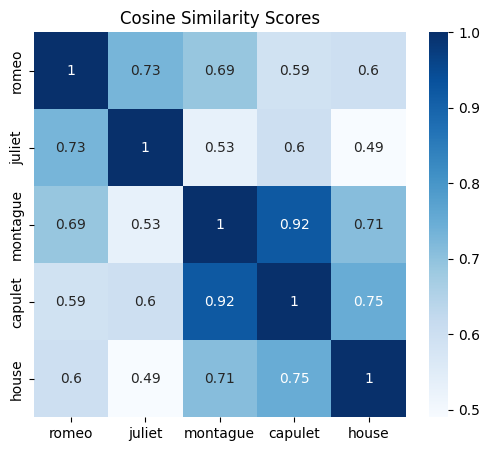

In [ ]:
plot_similarities(vectors, labels)

A Skip-Gramnak van egy másik változata, a **skip-gram negatív mintavételezéssel (SGNS)**:

1. A célszót és a szomszédos kontextusszavakat pozitív példákként kezeljük.
2. Véletlenszerűen mintavételezünk más szavakat a szókincsből, hogy negatív mintákat kapjunk.
3. Egy bináris osztályozót tanítunk, hogy megkülönböztesse a két esetet (címkék: pozitív, negatív).
4. A tanult súlyokat használjuk beágyazásként.

[forrás](https://web.stanford.edu/~jurafsky/slp3/6.pdf)

**Folytonos szózsák (Continuous Bag of Words - CBOW)**: a célszó előrejelzése a kontextus alapján.

Hasonló a Skip-Gramhoz. A modell bemenete a kontextusszavakból áll: a kontextusszavak one-hot kódolt vektorait összegezzük, hogy a teljes kontextust kódoljuk, pl.

| Szavak: | brown | dog | fox | jumped | lazy | over | quick | the |  .  |
| :------ | :---: | :-: | :-: | :----: | :--: | :--: | :-:   | :-: | :-: |
| Id-k:   | 0     | 1   | 2   | 3      | 4    | 5    | 6     | 7   | 8   |

A célszó a "fox" és az ablakméret 2:

```
text = "the quick brown fox jumped over the lazy dog."
context_1 = [0, 0, 0, 0, 0, 0, 1, 0, 0]
context_2 = [1, 0, 0, 0, 0, 0, 0, 0, 0]
context_3 = [0, 0, 0, 1, 0, 0, 0, 0, 0]
context_4 = [0, 0, 0, 0, 0, 1, 0, 0, 0]

input     = [1, 0, 0, 1, 0, 1, 1, 0, 0]
```

Ezután megpróbáljuk előrejelezni a célszót ebből. Vegyük észre, hogy így elveszítjük a kontextus pozícionális információját – ezért nevezzük szózsáknak.

**Skaláris szorzat**

Amikor van egy $\mathbf{v_1}$ vektorunk, általában oszlopvektorként gondolunk rá: $\mathbf{v_1} = \begin{bmatrix}3 \\-1 \\5\end{bmatrix}$ és a $\mathbf{v_1}^T$ jelölés a vektor (vagy mátrix) [transzponáltját](https://hu.wikipedia.org/wiki/Transzpon%C3%A1lt_m%C3%A1trix) jelenti: $\mathbf{v_1}^T =\begin{bmatrix}3 & -1 & 5\end{bmatrix}$. A skaláris szorzatot mátrixszorzásként írhatjuk: $\mathbf{v_1} \cdot \mathbf{v_2} = \mathbf{v_1^T} \mathbf{v_2} = \begin{bmatrix}3 & -1 & 5\end{bmatrix} \begin{bmatrix}1 \\ 0 \\ 2\end{bmatrix} = 3*1 + (-1)*0 + 5*2 = 13$

## GloVe (Global Vectors for Word Representation)

A **GloVe**, a *word2vec*-hez hasonlóan, sűrű szóbeágyazások előállítására szolgáló módszer.

---

### 1. Szó együtt-előfordulási mátrix $X$ felépítése

- Megszámoljuk, milyen gyakran fordulnak elő szavak egymás közelében egy kontextusablakban  
  (pl. 3 szó előtte és utána).
- Az $X_{ij}$ azt jelenti, milyen gyakran fordul elő az $i$ szó a $j$ szó közelében  
  a tanító szövegben.

---

### 2. A mátrix faktorizálása

A cél olyan szóvektorok megtalálása, amelyek jól közelítik az együtt-előfordulási mátrixot.

- Legyen:
  - $w_i$ az $i$ szó beágyazási vektora
  - $\widetilde{w}_j$ a $j$ kontextusszó beágyazási vektora

Ekkor a cél:

$$
w_i^\top \widetilde{w}_j \approx \log(X_{ij})
$$

- A logaritmus használata segít normalizálni a nagy előfordulási értékeket.
- Eltolás (*bias*) tagokat adunk hozzá a szimmetria helyreállításához:

$$
w_i^\top \widetilde{w}_j + b_i + \widetilde{b}_j \approx \log(X_{ij})
$$

---

### 3. Tanítás veszteségfüggvénnyel

A tanításhoz **súlyozott legkisebb négyzetek** veszteséget használunk:

$$
J = \sum_{i,j=1}^{V}
f(X_{ij})
\left(
w_i^\top \widetilde{w}_j + b_i + \widetilde{b}_j - \log(X_{ij})
\right)^2
$$

ahol a súlyozófüggvény:

$$
f(x) =
\begin{cases}
\left( \dfrac{x}{x_{\max}} \right)^{\alpha}, & \text{ha } x < x_{\max} \\
1, & \text{egyébként}
\end{cases}
$$

- $x_{\max}$ és $\alpha$ hiperparaméterek

---

Két mátrixot tanulunk:

- $W$ - szóbeágyazások
- $\widetilde{W}$ - kontextusbeágyazások

**Forrás:**  
[Pennington et al., 2014 - GloVe](https://nlp.stanford.edu/pubs/glove.pdf)


### Adathalmaz

In [ ]:
def build_cooccurrence_matrix(corpus, vocab_size=1000, window_size=2):
    words = corpus.split()
    word_counts = Counter(words)
    vocab = {word: i for i, (word, _) in enumerate(word_counts.most_common(vocab_size))}

    co_matrix = np.zeros((vocab_size, vocab_size))

    for i, word in enumerate(words):
        if word not in vocab:
            continue

        word_idx = vocab[word]
        for j in range(1, window_size + 1):
            if i - j >= 0 and words[i - j] in vocab:
                left_word_idx = vocab[words[i - j]]
                co_matrix[word_idx, left_word_idx] += 1
                co_matrix[left_word_idx, word_idx] += 1  # Szimmetrikus

            if i + j < len(words) and words[i + j] in vocab:
                right_word_idx = vocab[words[i + j]]
                co_matrix[word_idx, right_word_idx] += 1
                co_matrix[right_word_idx, word_idx] += 1

    return co_matrix, vocab


text_path = os.path.join("..", "data", "shakespeare.txt")
with open(text_path, 'r') as file:
    text = file.read().strip().lower()

co_matrix, vocab = build_cooccurrence_matrix(text, vocab_size=700, window_size=3)

# Együtt-előfordulási mátrix tensorrá alakítása
X = torch.tensor(co_matrix, dtype=torch.float32)

### GloVe modell

In [ ]:
class GloveModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GloveModel, self).__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.word_biases = nn.Embedding(vocab_size, 1)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_biases = nn.Embedding(vocab_size, 1)


        nn.init.xavier_uniform_(self.word_embeddings.weight)
        nn.init.zeros_(self.word_biases.weight)
        nn.init.xavier_uniform_(self.context_embeddings.weight)
        nn.init.zeros_(self.context_biases.weight)

        self.x_max = 100
        self.alpha = 3/4

    def forward(self, word_idx, context_idx, cooccurrence):
        w_i = self.word_embeddings(word_idx)
        w_j = self.context_embeddings(context_idx)
        b_i = self.word_biases(word_idx).squeeze()
        b_j = self.context_biases(context_idx).squeeze()

        # súlytényező
        weight_factor = torch.pow(cooccurrence / self.x_max, self.alpha)
        weight_factor[cooccurrence >= self.x_max] = 1

        # GloVe veszteség kiszámítása
        embedding_products = torch.sum(w_i * w_j, dim=1)
        log_cooccurrences = torch.log(cooccurrence)

        distance_expr = (embedding_products + b_i + b_j - log_cooccurrences) ** 2

        single_losses = weight_factor * distance_expr
        sum_loss = torch.sum(single_losses)

        return sum_loss

### Tanítás

In [ ]:
embedding_dim = 10

glove_model = GloveModel(len(vocab), embedding_dim)
optimizer = optim.Adam(glove_model.parameters(), lr=0.01)

word_idx, context_idx = torch.nonzero(X, as_tuple=True)
cooccurrence = X[word_idx, context_idx]

epochs = 3000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = glove_model(word_idx, context_idx, cooccurrence)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Veszteség: {loss.item():.4f}")

Epoch 100/3000, Veszteség: 758.6898
Epoch 200/3000, Veszteség: 545.2197
Epoch 300/3000, Veszteség: 450.7641
Epoch 400/3000, Veszteség: 412.6734
Epoch 500/3000, Veszteség: 391.4104
Epoch 600/3000, Veszteség: 378.4314
Epoch 700/3000, Veszteség: 370.5977
Epoch 800/3000, Veszteség: 365.8459
Epoch 900/3000, Veszteség: 362.7073
Epoch 1000/3000, Veszteség: 360.4582
Epoch 1100/3000, Veszteség: 358.8068
Epoch 1200/3000, Veszteség: 357.5548
Epoch 1300/3000, Veszteség: 356.5634
Epoch 1400/3000, Veszteség: 355.7550
Epoch 1500/3000, Veszteség: 355.0777
Epoch 1600/3000, Veszteség: 354.4710
Epoch 1700/3000, Veszteség: 353.9733
Epoch 1800/3000, Veszteség: 353.5850
Epoch 1900/3000, Veszteség: 353.2767
Epoch 2000/3000, Veszteség: 353.0271
Epoch 2100/3000, Veszteség: 352.8191
Epoch 2200/3000, Veszteség: 352.6399
Epoch 2300/3000, Veszteség: 352.4799
Epoch 2400/3000, Veszteség: 352.3356
Epoch 2500/3000, Veszteség: 352.2075
Epoch 2600/3000, Veszteség: 352.0960
Epoch 2700/3000, Veszteség: 351.9990
Epoch 2800

### Eredmények

In [ ]:
def get_embedding(word, vocab, model):
    if word in vocab:
        idx = torch.tensor(vocab[word])
        return model.word_embeddings(idx).detach().cpu().numpy()
    else:
        return None

romeo_vector = get_embedding("romeo", vocab, glove_model)
juliet_vector = get_embedding("juliet", vocab, glove_model)
montague_vector = get_embedding("montague", vocab, glove_model)
capulet_vector = get_embedding("capulet", vocab, glove_model)
house_vector = get_embedding("house", vocab, glove_model)

vectors = [
    romeo_vector,
    juliet_vector,
    montague_vector,
    capulet_vector,
    house_vector
]

labels = [
    "romeo",
    "juliet",
    "montague",
    "capulet",
    "house"
]


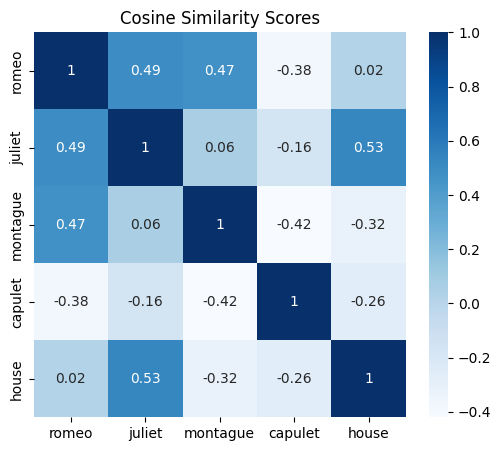

In [ ]:
plot_similarities(vectors, labels)